In [1]:
import os
os.chdir("../")

In [7]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


from corrosion2d.configs.train_fno_pi import Configs
configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})


save_fig_dir = "./figures/"

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


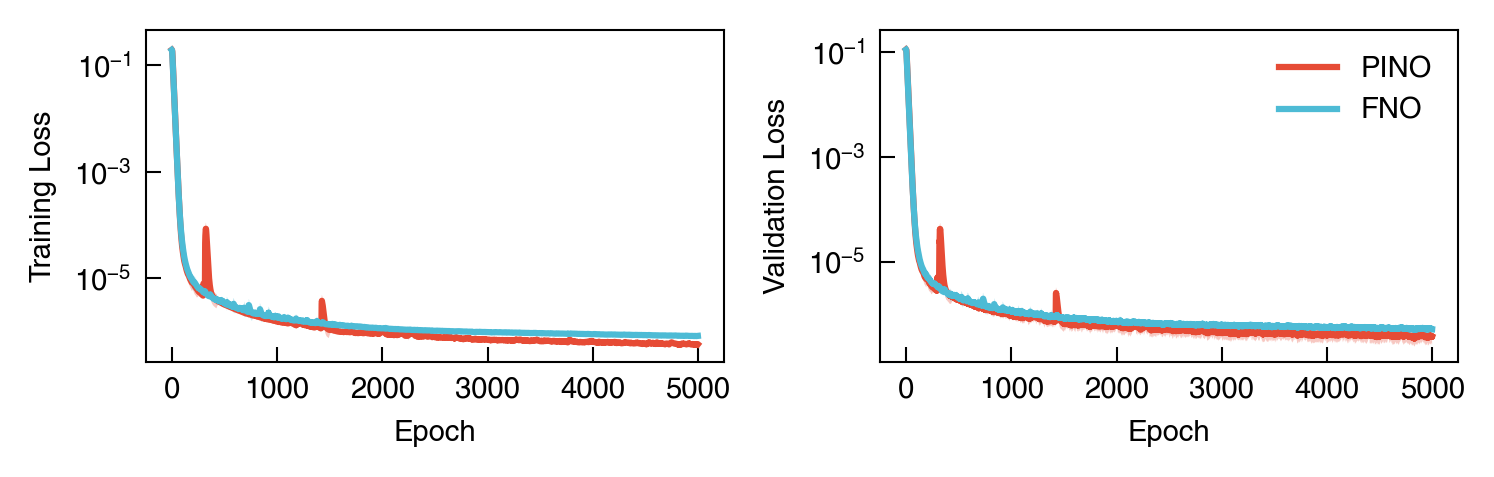

In [10]:
# read csv loss
import pandas as pd
save_dir_pino = "/root/autodl-tmp/runs/corrosion2d/FNO-PI/"
save_dir_fno = "/root/autodl-tmp/runs/corrosion2d/FNO/"

dirs = [
    (save_dir_pino, "PINO"),
    # (save_dir_pino_ds2, "PINO-DS"),
    (save_dir_fno, "FNO"),
    # (save_dir_pino_in, "PINO-INCPT"), # inception-enhanced PINO
    # (save_dir_fno_ds2, "FNO-DS"),
    # (save_dir_unet, "UNet"),
    # (save_dir_fcn, "FCN"),
]
import numpy as np
def smooth_and_ci_ewma(series, alpha=0.1):
    """使用指数加权移动平均，对异常值不敏感"""
    s = pd.Series(np.asarray(series, dtype=float))
    
    # 处理异常值
    s = s.replace([0, np.inf, -np.inf], np.nan)
    # s = s.fillna(method='ffill').fillna(method='bfill')
    s = s.ffill().bfill()
    
    # 指数加权移动平均
    ewm_mean = s.ewm(alpha=alpha, adjust=False).mean().to_numpy()
    ewm_std = s.ewm(alpha=alpha, adjust=False).std().to_numpy()
    
    # 限制置信区间
    ewm_std = np.nan_to_num(ewm_std)
    ci = np.minimum(1.96 * ewm_std, 0.3 * np.abs(ewm_mean))
    
    return ewm_mean, ci


fig, axes = plt.subplots(1, 2, figsize=(5.0, 1.6),)
for idx, (dir_path, model_name) in enumerate(dirs):
    loss_df = pd.read_csv(os.path.join(dir_path, "logs.csv"))
    
    ax = axes[0]
    # ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label=model_name)
    avg, ci = smooth_and_ci_ewma(loss_df["TrainLoss"].values, alpha=0.1)
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], avg - ci, avg + ci, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    
    ax = axes[1]
    # ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label=model_name)
    avg, ci = smooth_and_ci_ewma(loss_df["ValidLoss"].values, alpha=0.1)
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], avg - ci, avg + ci, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    
    ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "corrosion2d_training_validation_loss.pdf"), dpi=300, bbox_inches='tight', pad_inches=0.0)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


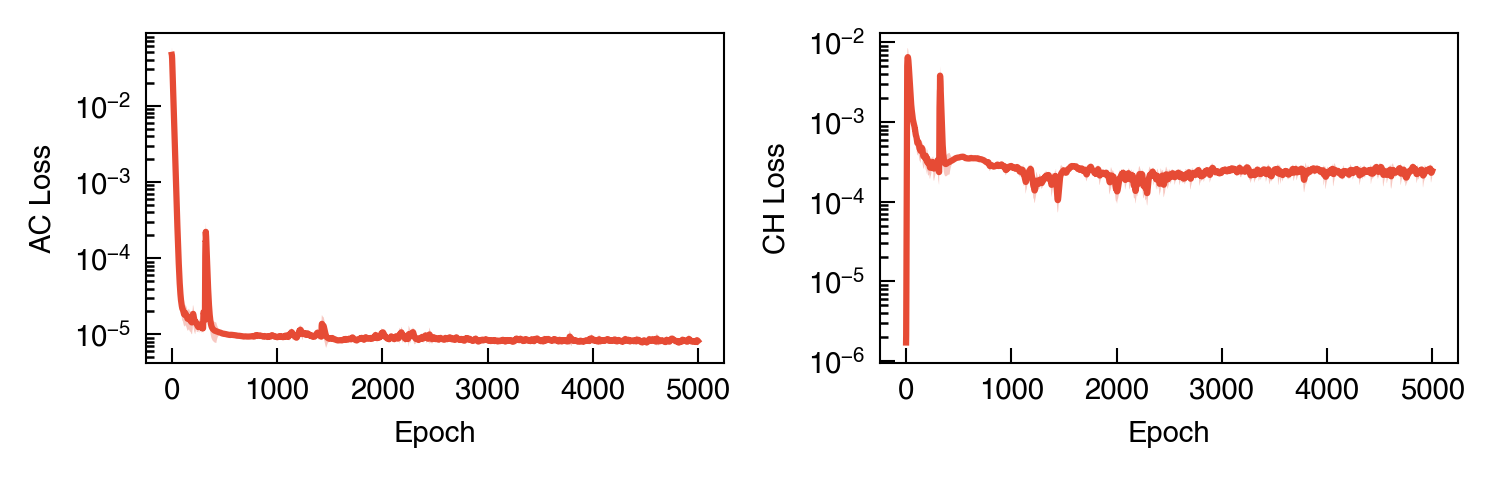

In [11]:
def smooth_and_ci_ewma(series, alpha=0.1):
    """使用指数加权移动平均，对异常值不敏感"""
    s = pd.Series(np.asarray(series, dtype=float))
    
    # 处理异常值
    s = s.replace([0, np.inf, -np.inf], np.nan)
    # s = s.fillna(method='ffill').fillna(method='bfill')
    s = s.ffill().bfill()
    
    # 指数加权移动平均
    ewm_mean = s.ewm(alpha=alpha, adjust=False).mean().to_numpy()
    ewm_std = s.ewm(alpha=alpha, adjust=False).std().to_numpy()
    
    # 限制置信区间
    ewm_std = np.nan_to_num(ewm_std)
    ci = np.minimum(1.96 * ewm_std, 0.3 * np.abs(ewm_mean))
    
    return ewm_mean, ci

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 1.6))
pino_loss_df = pd.read_csv(os.path.join(save_dir_pino, "logs.csv"))

ax = axes[0]
mean, ci = smooth_and_ci_ewma(pino_loss_df["ACLoss"].values, alpha=0.1)
ax.plot(pino_loss_df["Epoch"], mean, label="PINO")
ax.fill_between(pino_loss_df["Epoch"], mean - ci, mean + ci, alpha=0.3)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("AC Loss")

ax = axes[1]
mean, ci = smooth_and_ci_ewma(pino_loss_df["CHLoss"].values, alpha=0.1)
ax.plot(pino_loss_df["Epoch"], mean, label="PINO")
ax.fill_between(pino_loss_df["Epoch"], mean - ci, mean + ci, alpha=0.3)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("CH Loss")

fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "corrosion2d_ac_ch_loss.pdf"), dpi=300, bbox_inches='tight', pad_inches=0.0)

Text(0, 0.5, 'Test MSE Loss (100 steps)')

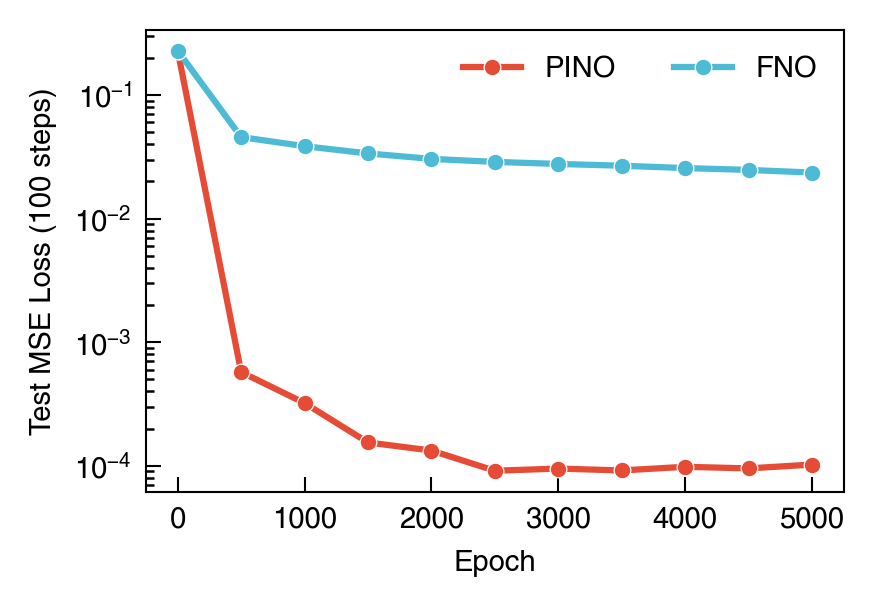

In [5]:
# test_df_fno = pd.read_csv(os.path.join(save_dir_fno, "test_logs.csv"))
# test_df_pino = pd.read_csv(os.path.join(save_dir_pino, "test_logs.csv"))

fig, ax = plt.subplots(1, 1, figsize=(3.0, 2.0))
# ax.plot(test_df_fno["Epoch"], test_df_fno["TestMSE"], label="FNO", marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
# ax.plot(test_df_pino["Epoch"], test_df_pino["TestMSE"], label="PINO", marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)

for dir_path, model_name in dirs:
    test_df = pd.read_csv(os.path.join(dir_path, "test_logs.csv"))
    ax.plot(test_df["Epoch"], test_df["TestMSE"], label=model_name, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
    

ax.legend(ncol=2)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test MSE Loss (100 steps)")
# ax_in = ax.inset_axes([0.2, 0.2, 0.47, 0.47], xlim=(8000, 10000), ylim=(1e-5, 1e-3), yscale="log")
# for dir_path, model_name in dirs:
#     test_df = pd.read_csv(os.path.join(dir_path, "test_logs.csv"))
#     ax_in.plot(test_df["Epoch"], test_df["TestMSE"], label=model_name, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)

# fig.tight_layout()
# print("Final FNO Test MSE:", test_df_fno["TestMSE"].values[-1])
# print("Final PINO Test MSE:", test_df_pino["TestMSE"].values[-1])

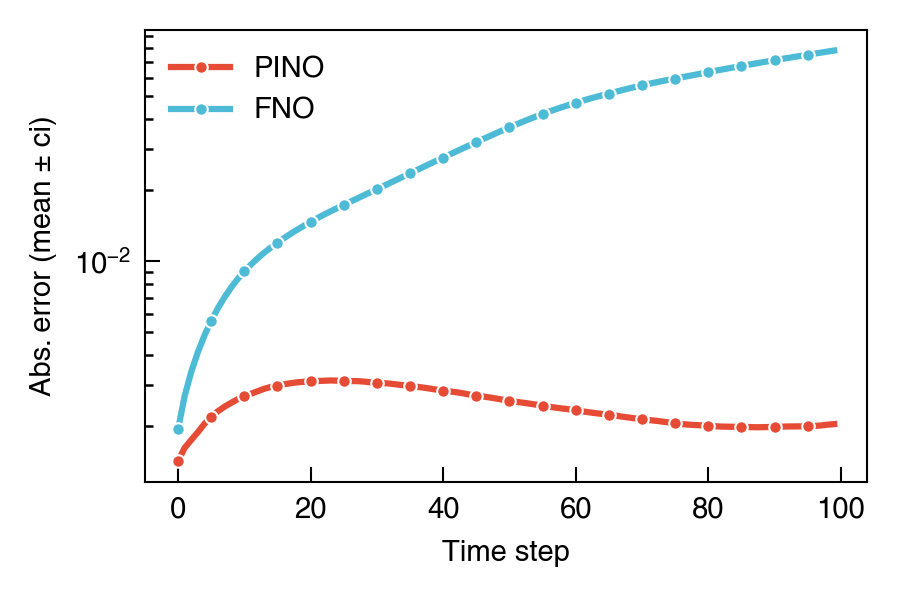

In [6]:
def plot_mean_with_std(ax, data, color, label):
    mean = jnp.mean(data, axis=0)
    std = jnp.std(data, axis=0, ddof=1)
    sem = std / jnp.sqrt(data.shape[0])
    ax.plot(mean, color=color, label=label, marker='o', markersize=3, 
            markeredgecolor="white", markevery=5, markeredgewidth=0.5)
    # ax.fill_between(
    #     jnp.arange(data.shape[1]),
    #     mean - 1.96 * sem,
    #     mean + 1.96 * sem,
    #     alpha=0.3,
    #     color=color
    # )
    

fig, ax = plt.subplots(1, 1, figsize=(3, 2))
for dir_path, model_name in dirs:
    test_results = jnp.load(os.path.join(dir_path, "test_results.npz"))
    y_test = test_results["y_test"]
    y_test_pred = test_results["y_test_pred"]
    error = jnp.abs(y_test - y_test_pred)
    mean_error = jnp.mean(error, axis=(2,3,4))
    # rel_l2 = jnp.linalg.norm(y_test - y_test_pred, axis=(2,3)) / jnp.linalg.norm(y_test, axis=(2,3))
    plot_mean_with_std(ax, mean_error, color="C"+str(dirs.index((dir_path, model_name))), label=model_name)
# plot_mean_with_std(ax, mean_error_fno, color="C0", label="FNO")
# plot_mean_with_std(ax, mean_error_pino, color="C1", label="PINO")
ax.legend()
ax.set_ylabel("Abs. error (mean \u00B1 ci)")
ax.set_yscale("log")
ax.set_xlabel("Time step")

fig.tight_layout()

## 加载模型并评估

In [7]:
save_fig_dir = "./figures/"

In [8]:
from corrosion2d.model2d import get_model2d

model_kwargs = {
   'modes_x': configs.modes_x,
   'modes_y': configs.modes_x,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
   'inception': configs.inception,
}


model_skeleton = get_model2d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)

weight_pino = os.path.join(save_dir_pino, f"epoch_{configs.epochs - 1}.eqx")
model_pino = eqx.tree_deserialise_leaves(weight_pino, model_skeleton)
weight_fno = os.path.join(save_dir_fno, f"epoch_{configs.epochs - 1}.eqx")
model_fno = eqx.tree_deserialise_leaves(weight_fno, model_skeleton)

In [9]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["times"]
dt = times[1] - times[0]
meshes = jnp.transpose(meshes, (2, 0, 1))
meshesx = meshes[0]
meshesy = meshes[1]
Xs.shape, Ys.shape

((250, 5, 51, 101), (250, 2, 51, 101))

In [10]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid_initials.npy"))
u0 = test_solutions[:, 0, :, :]
y_test = test_solutions[:, 1:, :, :]
auto_reg_fn_pino = partial(
    model_pino.auto_reg,
    meshes=meshes,
    dt=dt,
    steps=100
)
u_preds = jax.vmap(auto_reg_fn_pino)(u0)  # (num_test, steps, H, W)

auto_reg_fn_fno = partial(
    model_fno.auto_reg,
    meshes=meshes,
    dt=dt,
    steps=100
)
u_preds_fno = jax.vmap(auto_reg_fn_fno)(u0)

u_preds.shape, u_preds_fno.shape

((5, 100, 2, 51, 101), (5, 100, 2, 51, 101))

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


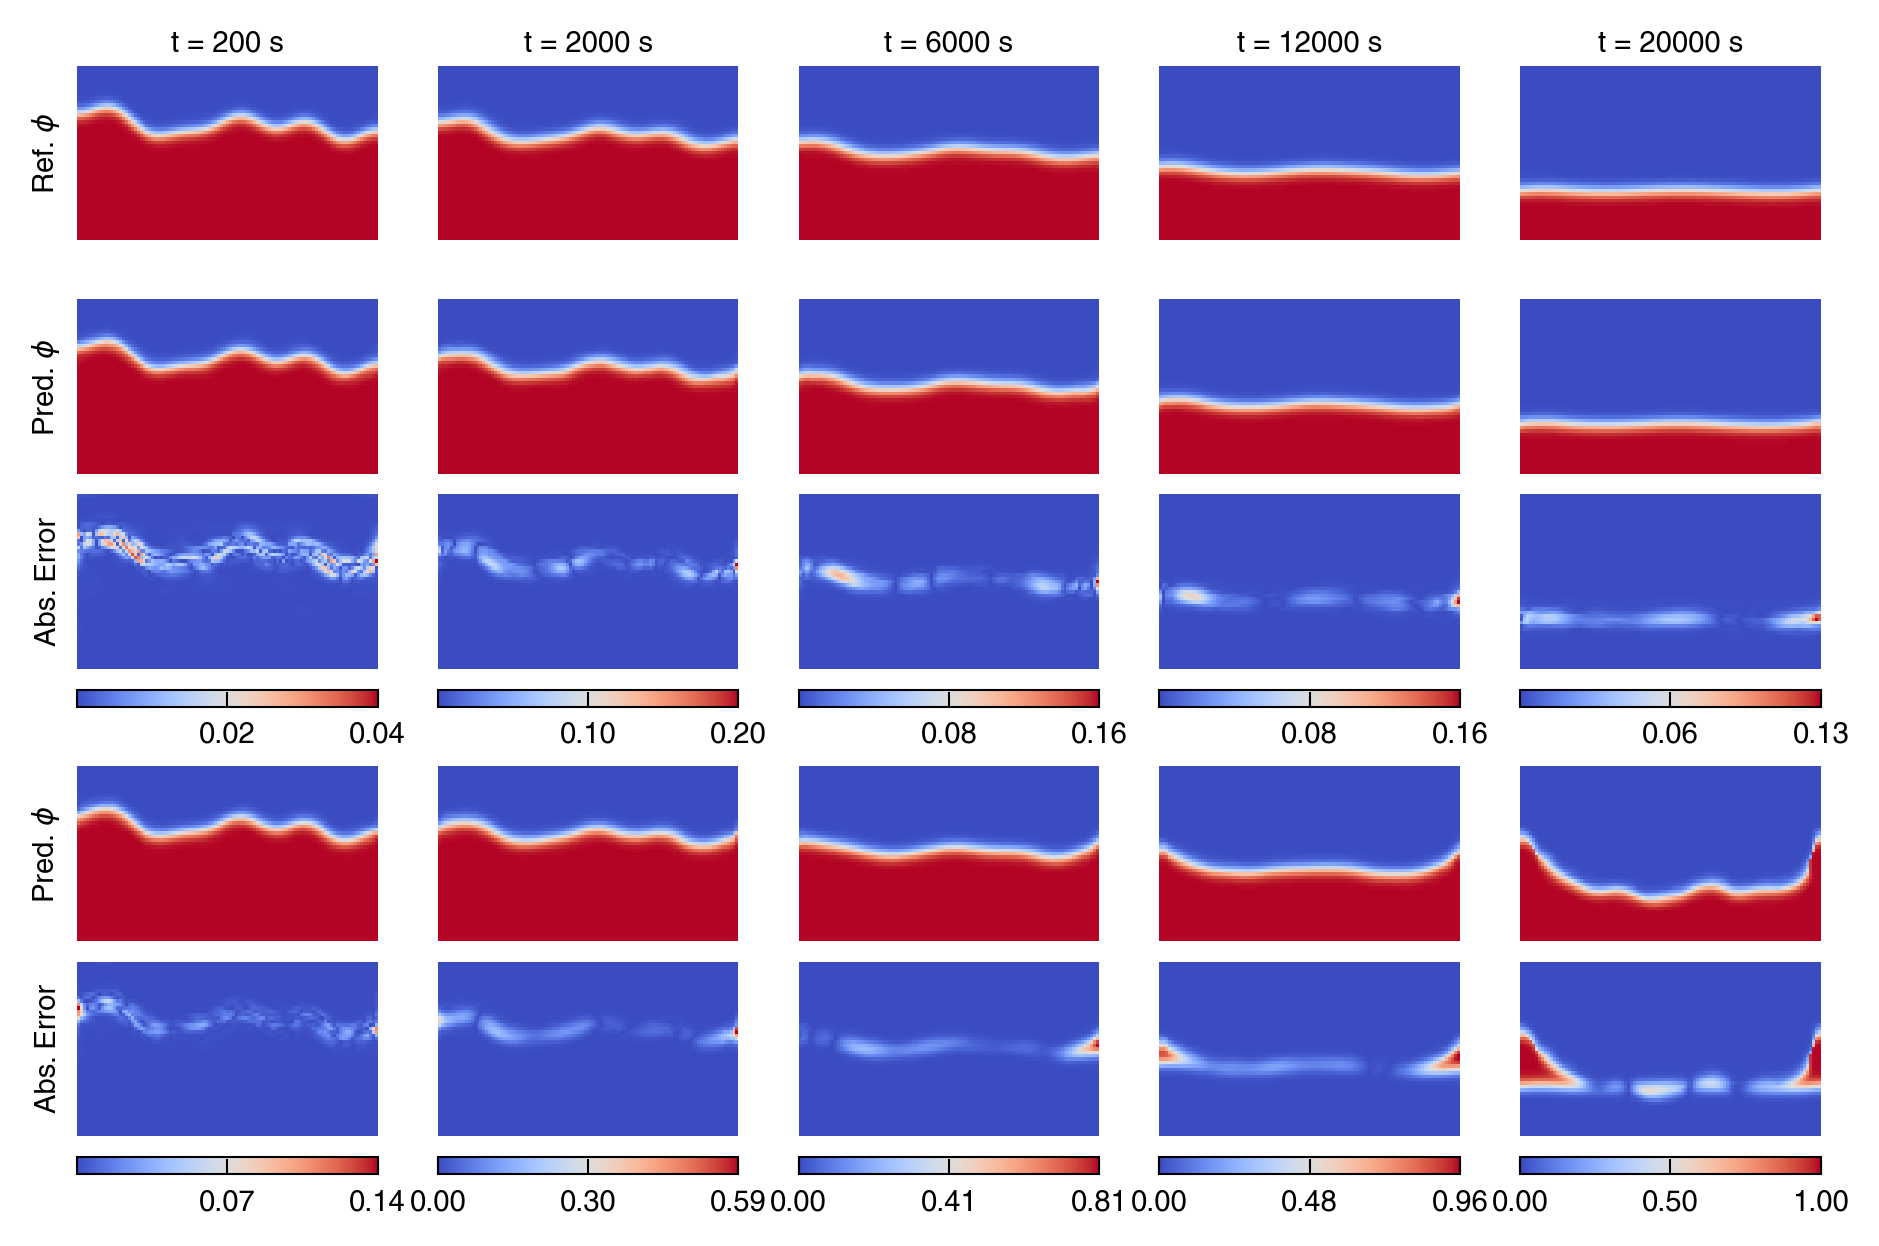

In [11]:
idxs = [0, 9, 29,59,  99]
meshesx = meshes[0]
meshesy = meshes[1]
example_th = 4
from matplotlib import gridspec as gs
fig = plt.figure(figsize=(1.5 * len(idxs), 4.8))
gs = fig.add_gridspec(9, len(idxs), width_ratios=[1]*len(idxs), height_ratios=[1,0.1,1,1,0.1,0.1,1,1,0.1])
# fig, axes = plt.subplots(3, len(idxs), figsize=(1.4 * len(idxs), 2.5))
for i, idx in enumerate(idxs):

    ax = fig.add_subplot(gs[0, i])
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, 0, :, :], cmap='coolwarm',rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Ref. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.set_aspect('auto')
    ax.text(0.5, 1.05, f"t = {int((idx+1)*dt*configs.Tc)} s", ha="center", va="bottom", transform=ax.transAxes)


    ax = fig.add_subplot(gs[2, i])
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, 0, :, :],  cmap='coolwarm',rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('auto')


    ax = fig.add_subplot(gs[3, i])
    diff = jnp.abs(y_test[example_th, idx, 0, :, :] - u_preds[example_th, idx, 0, :, :])
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, cmap='coolwarm',rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('auto')
    

    ax = fig.add_subplot(gs[4, i])
    fig.colorbar(diff_ax, cax=ax, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3),
                 pad=0.1, )
    
    ax = fig.add_subplot(gs[6, i])
    ax.pcolormesh(meshesx, meshesy, u_preds_fno[example_th, idx, 0, :, :],  cmap='coolwarm',rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('auto')

    ax = fig.add_subplot(gs[7, i])
    diff_fno = jnp.abs(y_test[example_th, idx, 0, :, :] - u_preds_fno[example_th, idx, 0, :, :])
    diff_ax_fno = ax.pcolormesh(meshesx, meshesy, diff_fno, cmap='coolwarm',rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('auto')

    ax = fig.add_subplot(gs[8, i])
    fig.colorbar(diff_ax_fno, cax=ax, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff_fno), num=3),
                 pad=0.1, )
    
# fig.subplots_adjust(hspace=0.01, wspace=0.2)
# fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "corrosion2d_test_sol.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


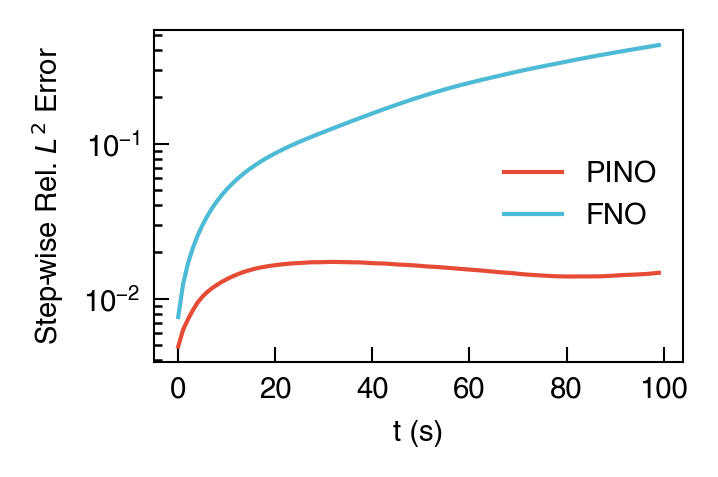

In [12]:
step_wise_l2_pino = jnp.linalg.norm(y_test - u_preds, axis=(-1,-2)) / jnp.linalg.norm(y_test, axis=(-1,-2))
step_wise_l2_fno = jnp.linalg.norm(y_test - u_preds_fno, axis=(-1,-2)) / jnp.linalg.norm(y_test, axis=(-1,-2))
step_wise_l2_pino = jnp.mean(step_wise_l2_pino, axis=(0, 2)) # avg over samples and channels
step_wise_l2_fno = jnp.mean(step_wise_l2_fno, axis=(0, 2)) # avg over samples and channels

fig, ax = plt.subplots(1, 1, figsize=(2.4, 1.6))
ax.plot(step_wise_l2_pino, label="PINO", lw=1)
ax.plot(step_wise_l2_fno, label="FNO", lw=1)
ax.set_yscale("log")
ax.set_xlabel(r"t (s)")
ax.set_ylabel("Step-wise Rel. $L^2$ Error")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "corrosion2d_stepwise_l2.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)

In [13]:
epochs = jnp.arange(0, configs.epochs, configs.test_every)

l2_pino_list = []
l2_fno_list = []

def compute_l2(model, x_test, y_test, test_meshes, dt):
    auto_reg_fn = partial(
        model.auto_reg,
        meshes=test_meshes,
        dt=jnp.array(dt),
        steps=100,
    )
    y_test_pred = jax.vmap(auto_reg_fn,)(x_test)

    # shape [sample, T, channel, spatialx, spatialy]
    # compute l2 on T, x, y
    # l2 = jnp.linalg.norm(y_test_pred - y_test, axis=(3,4)) / jnp.linalg.norm(y_test, axis=(3,4))
    l2 = jnp.sqrt(jnp.sum((y_test_pred - y_test) ** 2, axis=(1,3,4)) / jnp.sum(y_test ** 2, axis=(1,3,4)))
    l2 = jnp.mean(l2)  # avg over samples and channels
    return l2
    
for epoch in epochs:
    weight_pino = os.path.join(save_dir_pino, f"epoch_{epoch}.eqx")
    model_pino = eqx.tree_deserialise_leaves(weight_pino, model_skeleton)
    l2_pino = compute_l2(model_pino, u0, y_test, meshes, dt)
    l2_pino_list.append(l2_pino)
    weight_fno = os.path.join(save_dir_fno, f"epoch_{epoch}.eqx")
    model_fno = eqx.tree_deserialise_leaves(weight_fno, model_skeleton)
    l2_fno = compute_l2(model_fno, u0, y_test, meshes, dt)
    l2_fno_list.append(l2_fno)


2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Minimum L2 errors during training:
PINO: 0.014441057108342648
FNO: 0.2201695442199707


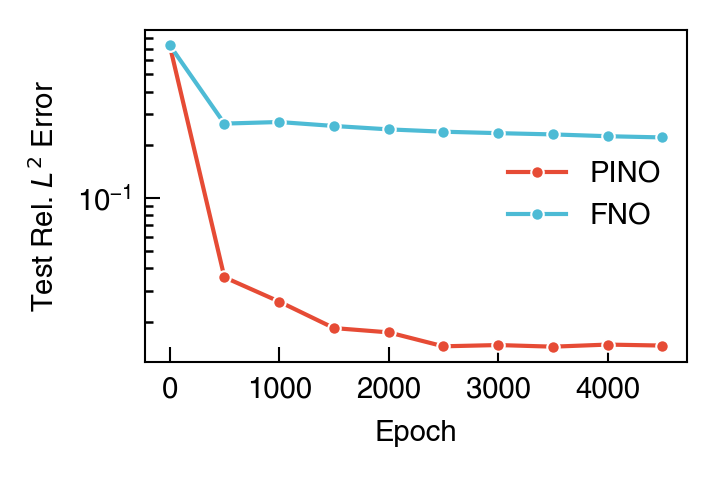

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(2.4, 1.6))
ax.plot(epochs, l2_pino_list, label="PINO", lw=1, marker='o', markersize=3, 
        markeredgecolor="white", markeredgewidth=0.5)
ax.plot(epochs, l2_fno_list, label="FNO", lw=1, marker='o', markersize=3,
        markeredgecolor="white", markeredgewidth=0.5)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Rel. $L^2$ Error")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "corrosion2d_test_l2.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)

print("Minimum L2 errors during training:")
print(f"PINO: {min(l2_pino_list)}")
print(f"FNO: {min(l2_fno_list)}")